In [25]:
#Librerias
import pandas as pd
import scipy as sc
import sympy as sp
import numpy as np
import h5py
import matplotlib.pylab as plt

In [26]:
#Datasets
data_train= "train_catvnoncat.h5"
train_dataset = h5py.File(data_train, "r")

data_test= "test_catvnoncat.h5"
test_dataset = h5py.File(data_test, "r")

In [27]:
train_dataset.keys()

<KeysViewHDF5 ['list_classes', 'train_set_x', 'train_set_y']>

In [28]:
# Read the data
xtrain_classes, xtrain, train_label =\
train_dataset["list_classes"],train_dataset["train_set_x"],train_dataset["train_set_y"]

test_classes, xtest,test_label =\
test_dataset["list_classes"],test_dataset["test_set_x"],test_dataset["test_set_y"]

In [29]:
np.shape(xtrain)

(209, 64, 64, 3)

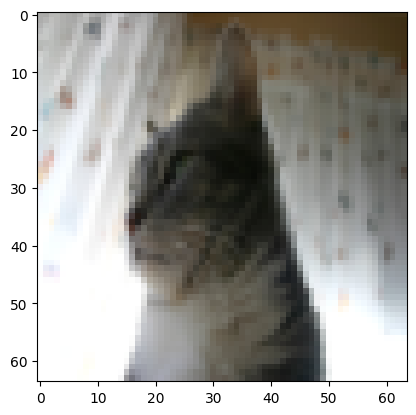

In [30]:
plt.imshow(xtrain[106])
plt.show()

In [31]:
np.shape(xtrain[0])

(64, 64, 3)

In [32]:
np.reshape(xtrain[0], 64*64*3)

array([17, 31, 56, ...,  0,  0,  0], shape=(12288,), dtype=uint8)

In [33]:
xtrain_= np.reshape(xtrain,(209, 64*64*3))/255
xtest_ = np.reshape(xtest,(50, 64*64*3))/255

In [34]:
len(xtrain_[208])

12288

## Topología de la red.

1. Construir un clase  que permita definir una red neuronal con la topología
deseada y la función de activación para cada capa, para ello deberá construir una funcion Topology con el número de capas de la red neuronal :

Topology = [n_x, n_h1, n_h2, n_h3, ...,n_y]

En este caso:
- $n^{[0]}=n_x$ seran los valores de entradas de la capa de entrada
- $n^{[1]}=n_{h1}$ Primera capa oculta de la red neuronal
- $n^{[2]}=n_{h2}$ Segunda capa oculta de la red neuronal

.

.

.


- $n^{[l]}=n_{hl}$ Segunda capa oculta de la red neuronal
.

.

.

- $n^{[L]}=n_{y}$ Segunda capa oculta de la red neuronal

donde

- $\mathrm{n_x}$: valores de entrada
- $\mathrm{n_{h1}}$: hidden layer 1
- $\mathrm{n_{h2}}$: hidden layer 2
- $\mathrm{n_y}$: last layer

- $n^{[L]}=n_{y}$ Segunda capa oculta de la red neuronal


También definir una lista con las funciones de activaciones para cada capa.


activation=[None, relu, relu, relu, ...,sigmoid]

  


a. Cada unas de las capas deberá tener los parámetros de inicialización de manera aleatoria:


La matriz de parametros para cada capa debera tener:


$\mathrm{dim(\vec{b}^{[l]})}=n^{[l]}$

$\mathrm{dim(\vec{\Theta}^{[l]})}=n^{[l]}\times n^{[l-1]}$

Lo anteriores parametros deberán estar en el constructor de la clase.


b. Construya un metodo llamado output cuya salida serán los valores de Z y A


$\mathrm{dim(\vec{\cal{A}}^{[l]})}=n^{[l-1]}\times m $

$\mathrm{dim(\vec{\cal{Z}}^{[l]})}=n^{[l]}\times m $.


Se sugiere para cada capa emplear programación orientada a objetos definida de la siguiente manera:

```
class layer_nn():
  def __init__(self, act_fun, nlayer_present, nlayer_before):
    self.theta = 2*np.random.random((nlayer_present, nlayer_before)) - 1
    self.B = 2*np.random.random((nlayer_present,1)) - 1
    self.act_fun = act_fun

  def output(self, Z, A):
    self.Z = Z
    self.A = A



def act_function(x, activation):
  if activation=="sigmoid":
    f = lambda x: 1/(1+np.exp(-x))
    fp = f(x)*(1-f(x))
    return f, fp
  
  elif activation == "tanh":
    f = lambda x: np.tanh
    return tanh
  else :
    return 0
```
    

In [35]:
class layer_nn():
  def __init__(self, func_act, nn_present, nn_before):
    np.random.seed(0)
    self.theta = 2*np.random.random((nn_present, nn_before)) - 1
    self.b = 2*np.random.random((nn_present, 1))-1
    self.func_acti = func_act

  def output(self, A, Z):
    self.A = A
    self.Z = Z


def activation_function(name, x):
  if (name=="sigmoid"):
    f = lambda x: 1/(1+np.exp(-x))
    return f(x)

  elif (name=="tanh"):
    f =  lambda x: np.tanh(x)
    return f(x)
  else :
    return "Error"


In [36]:
Y = np.array(train_label)

## Función de Costo y Variables de Entrenamiento

In [37]:
A0 = xtrain_.T

In [38]:
class layer_nn():
  def __init__(self, func_act, nn_present, nn_before):
    np.random.seed(0)
    self.theta = 2*np.random.random((nn_present, nn_before)) - 1
    self.b = 2*np.random.random((nn_present, 1))-1
    self.func_acti = func_act

  def output(self, A, Ap, Z):
    self.A = A
    self.Z = Z
    self.Ap = Ap

  def derivative(self, dtheta, db):
    self.dtheta = dtheta
    self.db = db

def activation_function(name, x):
  if (name=="sigmoid"):
    f = lambda x: 1/(1+np.exp(-x))
    fx = f(x)
    return fx, fx*(1-fx)

  elif (name=="tanh"):
    f =  lambda x: np.tanh(x)
    return f(x), 1-f(x)**2
  else :
    return "Error"

In [39]:
def build_red(Topology, act_func):
  L = len(Topology)
  red_nn=[]
  for i in range(1, L):
    li = layer_nn(act_func[i], Topology[i], Topology[i-1] )
    red_nn.append(li)
  return red_nn

## Forward Propagation

In [40]:
def forward_pass(A0, nn):
  update_nn = []
  for layer in nn:
    li = layer
    Zi = li.theta@A0 + li.b
    Aii, Ap = activation_function(li.func_acti, Zi)
    li.output(Aii, Ap,Zi)
    update_nn.append(li)
    A0 = Aii.copy()

  return Aii, update_nn

## Backward Propagation y Actualización de Parámetros

In [41]:
nx = 12288
Topology = [nx,3, 4, 7, 1 ]
act_func = ["sigmoid","sigmoid", "sigmoid", "sigmoid", "sigmoid"]
nn = build_red(Topology, act_func)

In [42]:
def cost_func(Y, A):
  m = Y.shape[0]
  ji = - ( Y*np.log(A)-(1-Y)*np.log(1-A))
  cost = ji.sum()
  return cost/m

## Red Neuronal Generalizada

Matriz de Confusión - ENTRENAMIENTO:
[[137   0]
 [ 72   0]]

Matriz de Confusión - PRUEBA:
[[17  0]
 [33  0]]


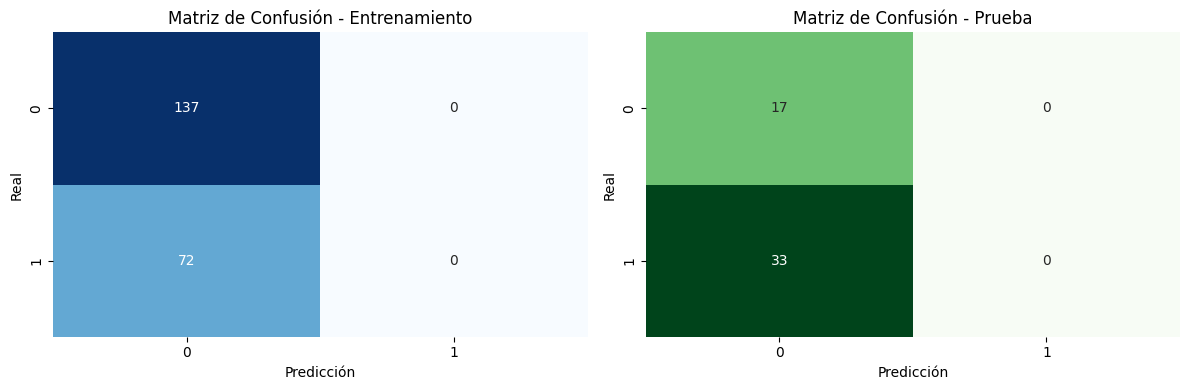


Reporte de Clasificación - PRUEBA:
              precision    recall  f1-score   support

     No Gato       0.34      1.00      0.51        17
        Gato       0.00      0.00      0.00        33

    accuracy                           0.34        50
   macro avg       0.17      0.50      0.25        50
weighted avg       0.12      0.34      0.17        50



c:\Users\Hogar\computacional_2\002_EstudiantesAprendizajeEstadistico\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Hogar\computacional_2\002_EstudiantesAprendizajeEstadistico\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Hogar\computacional_2\002_EstudiantesAprendizajeEstadistico\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_d

In [43]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Matriz de confusión en entrenamiento
cm_train = confusion_matrix(Y, Y_pred_train_binary[0])
print("Matriz de Confusión - ENTRENAMIENTO:")
print(cm_train)

# Matriz de confusión en prueba
cm_test = confusion_matrix(Y_test, Y_pred_test_binary[0])
print("\nMatriz de Confusión - PRUEBA:")
print(cm_test)

# Visualizar matrices de confusión
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Train confusion matrix
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Matriz de Confusión - Entrenamiento')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicción')

# Test confusion matrix
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False)
axes[1].set_title('Matriz de Confusión - Prueba')
axes[1].set_ylabel('Real')
axes[1].set_xlabel('Predicción')

plt.tight_layout()
plt.show()

print("\nReporte de Clasificación - PRUEBA:")
print(classification_report(Y_test, Y_pred_test_binary[0], target_names=['No Gato', 'Gato']))

In [44]:
def predict(X, nn):
  """
  Realiza predicciones con la red entrenada
  """
  A = X.T
  for layer in nn:
    Z = layer.theta @ A + layer.b
    A, _ = activation_function(layer.func_acti, Z)
  return A

# Predicciones en datos de entrenamiento
Y_pred_train = predict(xtrain_, nn)
Y_pred_train_binary = (Y_pred_train > 0.5).astype(int)
accuracy_train = np.mean(Y_pred_train_binary == Y) * 100

print(f"Accuracy en entrenamiento: {accuracy_train:.2f}%")

# Predicciones en datos de prueba
Y_pred_test = predict(xtest_, nn)
Y_pred_test_binary = (Y_pred_test > 0.5).astype(int)
Y_test = np.array(test_label)
accuracy_test = np.mean(Y_pred_test_binary == Y_test) * 100

print(f"Accuracy en prueba: {accuracy_test:.2f}%")

Accuracy en entrenamiento: 34.45%
Accuracy en prueba: 66.00%


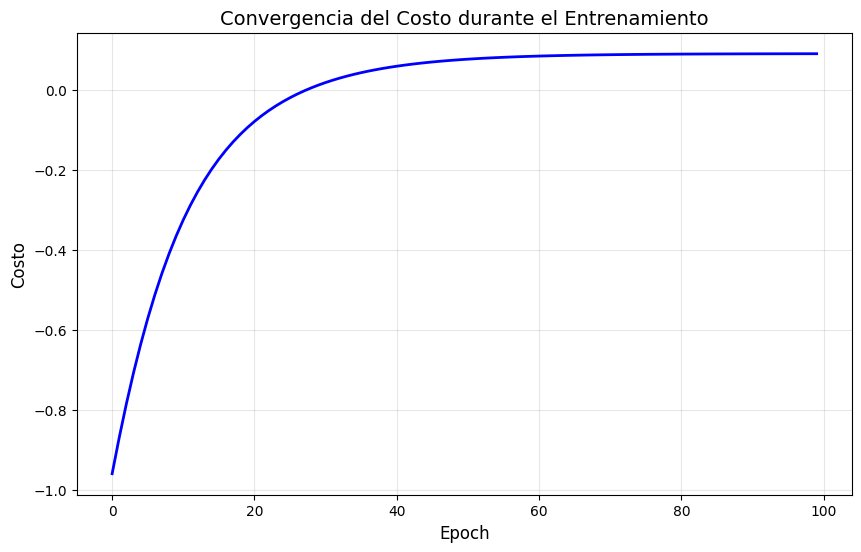


Mínimo costo alcanzado en epoch: 1 con valor -0.958800


In [45]:
# Gráfica de convergencia del costo
if len(costs) > 0:
  plt.figure(figsize=(10, 6))
  plt.plot(costs, 'b-', linewidth=2)
  plt.xlabel('Epoch', fontsize=12)
  plt.ylabel('Costo', fontsize=12)
  plt.title('Convergencia del Costo durante el Entrenamiento', fontsize=14)
  plt.grid(True, alpha=0.3)
  plt.show()

  print(f"\nMínimo costo alcanzado en epoch: {np.argmin(costs)+1} con valor {np.min(costs):.6f}")
else:
  print("Error: La lista 'costs' está vacía. Ejecuta primero la celda de entrenamiento.")

In [46]:
# Parámetros de entrenamiento
num_epochs = 100
learning_rate = 0.1
costs = []

print("Iniciando entrenamiento...")
print(f"Epochs: {num_epochs}, Learning Rate: {learning_rate}")
print("="*50)

for epoch in range(num_epochs):
  # Forward pass
  AL, update_nn = forward_pass(A0, nn)
  
  # Calcular costo
  J = cost_func(Y, AL)
  costs.append(J)
  
  # Backward pass
  update_nn = backward_pass(Y, AL, update_nn)
  
  # Actualizar parámetros
  nn = update_parameters(update_nn, learning_rate)
  
  if (epoch + 1) % 10 == 0:
    print(f"Epoch {epoch+1}/{num_epochs} - Costo: {J:.6f}")

print("="*50)
print("¡Entrenamiento completado!")
print(f"Costo inicial: {costs[0]:.6f}")
print(f"Costo final: {costs[-1]:.6f}")
print(f"Reducción: {((costs[0]-costs[-1])/costs[0]*100):.2f}%")

Iniciando entrenamiento...
Epochs: 100, Learning Rate: 0.1
Epoch 10/100 - Costo: -0.365026
Epoch 20/100 - Costo: -0.094509
Epoch 30/100 - Costo: 0.011815
Epoch 40/100 - Costo: 0.056154
Epoch 50/100 - Costo: 0.075276
Epoch 60/100 - Costo: 0.083654
Epoch 70/100 - Costo: 0.087350
Epoch 80/100 - Costo: 0.088986
Epoch 90/100 - Costo: 0.089712
Epoch 100/100 - Costo: 0.090034
¡Entrenamiento completado!
Costo inicial: -0.958800
Costo final: 0.090034
Reducción: 109.39%


In [47]:
def update_parameters(nn, learning_rate):
  """
  Actualiza los parámetros de la red usando gradient descent
  """
  for layer in nn:
    layer.theta = layer.theta - learning_rate * layer.dtheta
    layer.b = layer.b - learning_rate * layer.db
  return nn

## Entrenamiento y Evaluación

In [48]:
def backward_pass(Y, AL, update_nn):
  """
  Implementa la propagación hacia atrás para todas las capas
  """
  m = Y.shape[0]
  m_ = 1/m
  
  # Inicializar con dA de la última capa
  dAL = -(np.divide(Y, AL) - np.divide(1 - Y, 1 - AL))
  
  # Iterar hacia atrás por las capas
  dA = dAL
  for l in range(len(update_nn)-1, -1, -1):
    layer = update_nn[l]
    
    # Calcular dZ
    dZ = dA * layer.Ap
    
    # Calcular dTheta y db
    if l > 0:
      A_anterior = update_nn[l-1].A
    else:
      A_anterior = A0  # Para la primera capa
    
    dtheta = m_ * dZ @ A_anterior.T
    db = m_ * np.sum(dZ, axis=1, keepdims=True)
    
    # Propagar hacia atrás
    if l > 0:
      dA = np.dot(layer.theta.T, dZ)
    
    # Guardar gradientes en la capa
    layer.dtheta = dtheta
    layer.db = db
    
  return update_nn